In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.build_dataset import build_ml_dataset

df = build_ml_dataset()
print(f"✅ df chargé : {df.shape}")
print(df.columns.tolist())

🔍 Query : SELECT * FROM public."ml_dataset_final" 
✅ ml_dataset_final : 506,886 lignes × 64 colonnes
📊 506,886 lignes × 64 colonnes
Mortels : 13,599 / 506,886
✅ df chargé : (506886, 64)
['Num_Acc', 'id_usager', 'id_vehicule', 'gravite', 'graviter_blessure_label', 'gravite_binaire', 'sexe', 'sexe_label', 'annee_naissance', 'age_victime_jour', 'tranche_age', 'categorie_usager', 'categorie_usager_label', 'motif_trajet', 'motif_trajet_label', 'equipement_secu1', 'equipement_secu_1_label', 'equipement_secu2', 'equipement_secu_2_label', 'equipement_secu3', 'equipement_secu_3_label', 'localisation_pieton', 'localisation_pieton_label', 'action_pieton', 'action_pieton_label', 'categorie_vehicule', 'categorie_vehicule_label', 'motorisation', 'motorisation_label', 'obstacle_fixe', 'obstacle_fixe_label', 'obstacle_mobile', 'obstacle_mobile_label', 'date', 'annee_source', 'tranche_horaire_label', 'departement', 'label_departement', 'label_region', 'commune', 'lat', 'long', 'luminosite', 'luminosite

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Analyse de chaque colonne vs la cible ─────────────────────────────────────
def audit_features(df, target_col="gravite_binaire"):
    
    rapport = []
    
    for col in df.columns:
        if col in [target_col, "gravite", "Num_Acc", "id_usager", 
                   "id_vehicule", "annee_naissance", "date",
                   "commune", "lat", "long"]:
            continue
        
        infos = {
            "colonne"       : col,
            "dtype"         : str(df[col].dtype),
            "nb_unique"     : df[col].nunique(),
            "pct_nan"       : round(df[col].isna().mean() * 100, 1),
            "pct_inconnu"   : 0,
        }
        
        # % de valeurs "Inconnu" ou -1 (données manquantes déguisées)
        if df[col].dtype == object:
            infos["pct_inconnu"] = round(
                df[col].isin(["Inconnu", "Non renseigné", "-1", "nan"]).mean() * 100, 1
            )
        
        # Corrélation avec la cible (pour les numériques)
        if df[col].dtype in [np.float64, np.int64]:
            infos["corr_cible"] = round(df[col].corr(df[target_col]), 3)
        else:
            infos["corr_cible"] = None
            
        rapport.append(infos)
    
    return pd.DataFrame(rapport).sort_values("pct_nan", ascending=False)

rapport = audit_features(df)
print(rapport.to_string(index=False))

                  colonne   dtype  nb_unique  pct_nan  pct_inconnu  corr_cible
         equipement_secu3 float64         10     96.6          0.0       0.166
      localisation_pieton float64         10     47.5          0.0       0.011
         equipement_secu2 float64         10     44.2          0.0       0.061
            action_pieton  object         13     12.2          0.0         NaN
         age_victime_jour float64         97      6.1          0.0       0.077
              tranche_age  object          5      6.1          0.0         NaN
       regime_circulation float64          4      6.0          0.0       0.026
             label_region  object         13      5.8          0.0         NaN
        label_departement  object         96      5.8          0.0         NaN
    vitesse_max_autorisee float64         32      2.3          0.0       0.075
             motif_trajet float64          7      2.2          0.0       0.029
                     sexe float64          2      2.

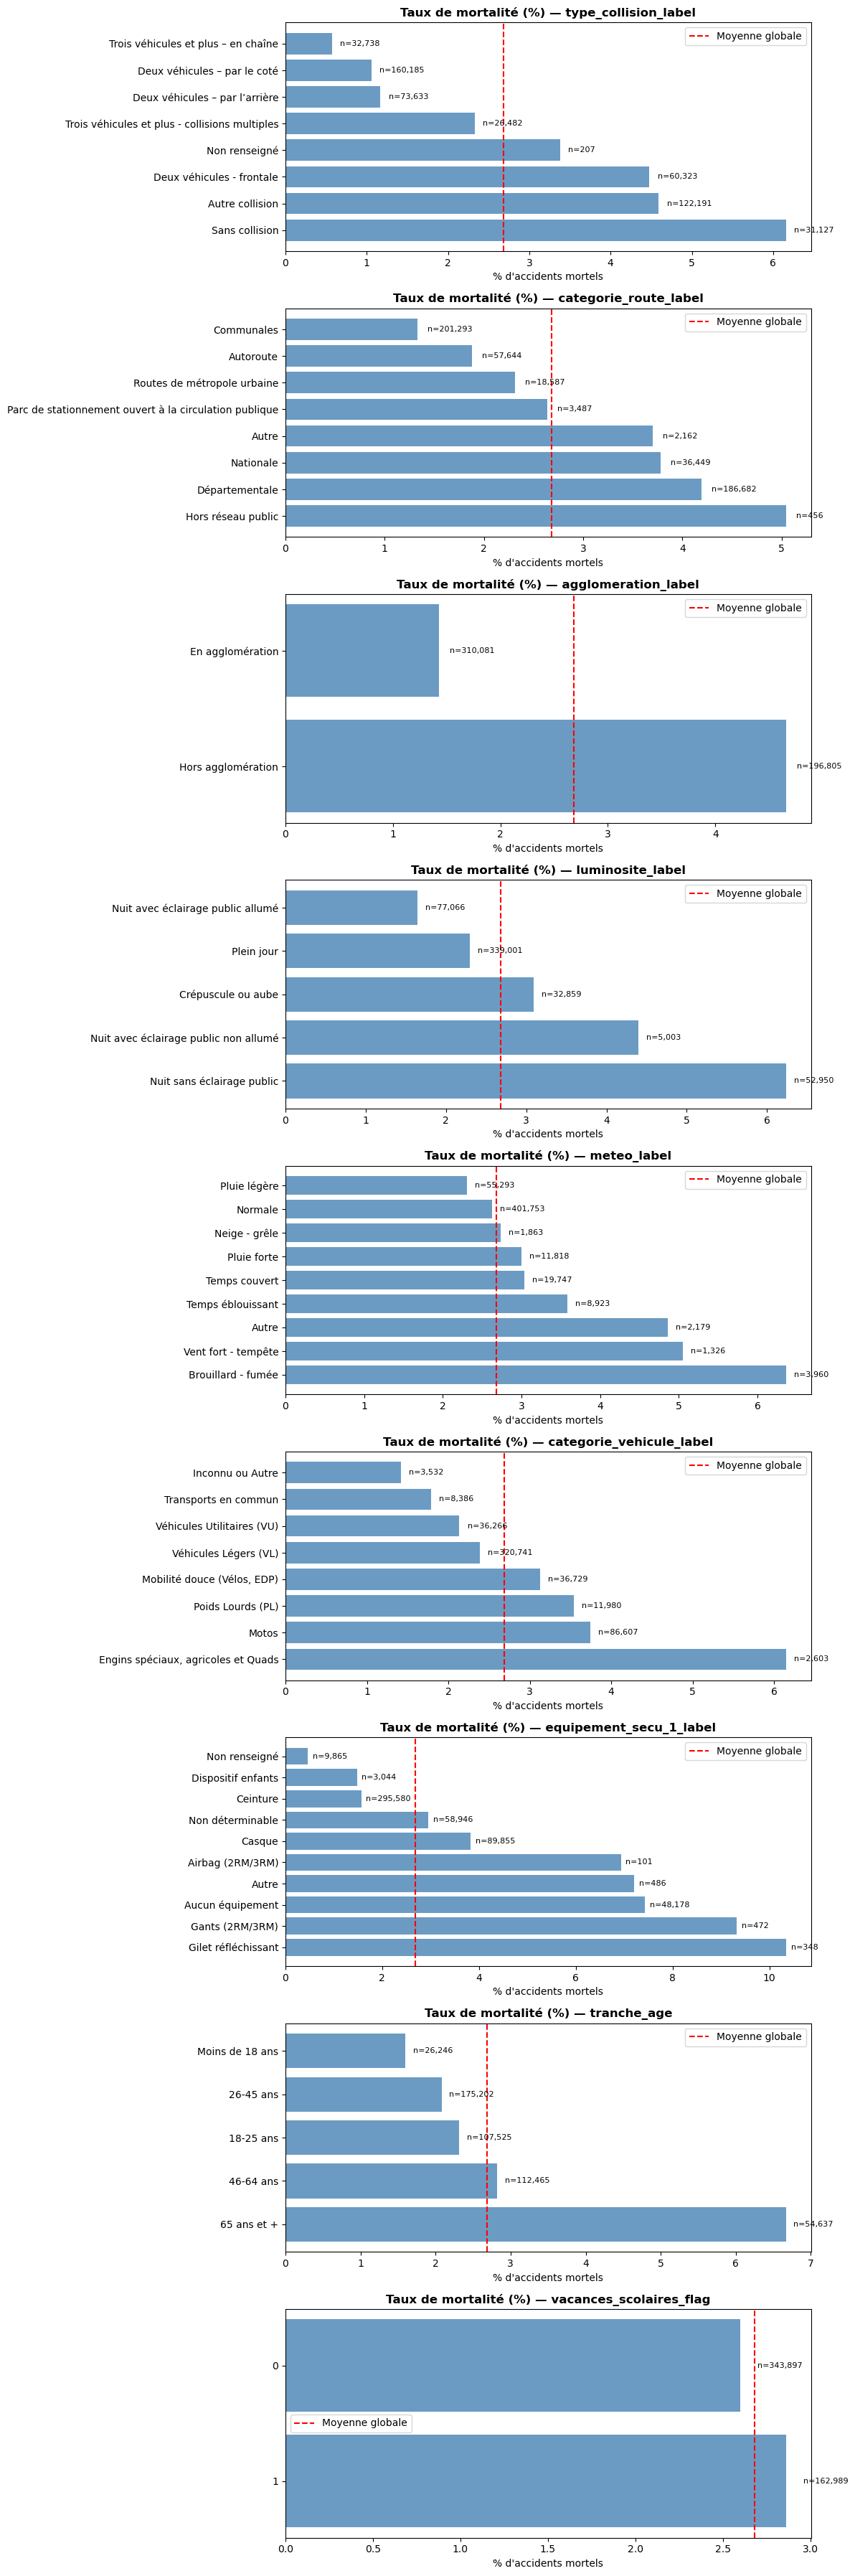

In [3]:
def taux_mortalite_par_modalite(df, colonnes, target="gravite_binaire"):
    """
    Pour chaque colonne catégorielle, calcule le taux de mortalité
    par modalité → révèle les vraies relations avec la cible.
    """
    fig, axes = plt.subplots(len(colonnes), 1, 
                              figsize=(12, 4 * len(colonnes)))
    if len(colonnes) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, colonnes):
        stats = (df.groupby(col)[target]
                   .agg(["mean", "count"])
                   .reset_index()
                   .rename(columns={"mean": "taux_mortalite", "count": "nb_accidents"})
                   .sort_values("taux_mortalite", ascending=False))
        
        # Filtre les modalités avec moins de 100 accidents (trop rares)
        stats = stats[stats["nb_accidents"] >= 100]
        
        bars = ax.barh(stats[col].astype(str), 
                       stats["taux_mortalite"] * 100,
                       color="steelblue", alpha=0.8)
        
        # Affiche le nombre d'accidents sur chaque barre
        for bar, n in zip(bars, stats["nb_accidents"]):
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                    f"n={n:,}", va="center", fontsize=8)
        
        ax.set_title(f"Taux de mortalité (%) — {col}", fontweight="bold")
        ax.set_xlabel("% d'accidents mortels")
        ax.axvline(df[target].mean() * 100, color="red", 
                   linestyle="--", label="Moyenne globale")
        ax.legend()
    
    plt.tight_layout()
    plt.show()


# ── Lance sur les colonnes les plus intéressantes ─────────────────────────────
taux_mortalite_par_modalite(df, colonnes=[
    "type_collision_label",
    "categorie_route_label",
    "agglomeration_label",
    "luminosite_label",
    "meteo_label",
    "categorie_vehicule_label",
    "equipement_secu_1_label",
    "tranche_age",
    "vacances_scolaires_flag",
])

In [4]:
def classification_colonnes(df, target="gravite_binaire"):
    """
    Classifie chaque colonne en : GARDER / TRANSFORMER / SUPPRIMER
    """
    decisions = []
    
    for col in df.columns:
        if col in [target, "gravite", "Num_Acc", "id_usager", 
                   "id_vehicule", "date"]:
            continue
        
        pct_nan     = df[col].isna().mean() * 100
        nb_unique   = df[col].nunique()
        
        # Valeurs manquantes déguisées
        if df[col].dtype == object:
            pct_inconnu = df[col].isin(
                ["Inconnu", "Non renseigné", "-1", "nan"]
            ).mean() * 100
        else:
            pct_inconnu = (df[col] == -1).mean() * 100
        
        # Règles de décision
        if pct_nan + pct_inconnu > 60:
            decision = "🔴 SUPPRIMER"
            raison   = f"Trop de NaN/Inconnu : {pct_nan+pct_inconnu:.0f}%"
        
        elif col in ["annee_source", "annee_naissance", "commune", 
                     "lat", "long", "label_departement"]:
            decision = "🔴 SUPPRIMER"
            raison   = "Non prédictif ou trop granulaire"
        
        elif col == "label_region":
            decision = "🟡 TRANSFORMER"
            raison   = "Remplacer par densité_accidents_region (feature engineered)"
        
        elif col == "sexe" and df[col].dtype in [np.float64, np.int64]:
            decision = "🟡 TRANSFORMER"
            raison   = "Passer en catégoriel (1=M / 2=F)"
        
        elif nb_unique > 50 and df[col].dtype == object:
            decision = "🟡 TRANSFORMER"
            raison   = f"Trop de modalités ({nb_unique}) → regrouper"
        
        elif nb_unique == 1:
            decision = "🔴 SUPPRIMER"
            raison   = "Variance nulle — aucune info"
        
        else:
            decision = "🟢 GARDER"
            raison   = ""
        
        decisions.append({
            "colonne"    : col,
            "decision"   : decision,
            "raison"     : raison,
            "nb_unique"  : nb_unique,
            "pct_nan"    : round(pct_nan, 1),
            "pct_inconnu": round(pct_inconnu, 1),
        })
    
    return pd.DataFrame(decisions).sort_values("decision")

decisions = classification_colonnes(df)
print(decisions.to_string(index=False))

                  colonne      decision                                                      raison  nb_unique  pct_nan  pct_inconnu
             annee_source   🔴 SUPPRIMER                            Non prédictif ou trop granulaire          4      0.0          0.0
                  commune   🔴 SUPPRIMER                            Non prédictif ou trop granulaire      22152      0.0          0.0
                      lat   🔴 SUPPRIMER                            Non prédictif ou trop granulaire     200565      0.0          0.0
                     long   🔴 SUPPRIMER                            Non prédictif ou trop granulaire     203967      0.0          0.0
        label_departement   🔴 SUPPRIMER                            Non prédictif ou trop granulaire         96      5.8          0.0
         equipement_secu3   🔴 SUPPRIMER                                   Trop de NaN/Inconnu : 97%         10     96.6          0.0
  equipement_secu_3_label   🔴 SUPPRIMER                              

In [7]:
def add_engineered_features(df):
    """
    Crée de nouvelles features plus prédictives que les colonnes brutes.
    """
    df = df.copy()
    
    # ── 1. Profil de risque usager ─────────────────────────────────────────────
    # Jeune homme sans ceinture = profil le plus mortel
    df["profil_risque"] = (
        (df["tranche_age"].isin(["18-24 ans", "25-34 ans"])).astype(int) +
        (df["sexe"] == 1).astype(int) +                          # homme
        (df["equipement_secu_1_label"] == "Non attaché").astype(int)
    )
    # 0 = profil standard, 1-2 = risque modéré, 3 = profil le plus à risque
    
    # ── 2. Route dangereuse ───────────────────────────────────────────────────
    df["route_dangereuse"] = (
        (df["agglomeration_label"] == "Hors agglomération").astype(int) +
        (df["categorie_route_label"].isin(["Route nationale", 
                                            "Route départementale"])).astype(int) +
        (df["etat_surface_label"].isin(["Mouillée", "Verglacée", 
                                         "Boueuse"])).astype(int)
    )
    
    # ── 3. Condition de visibilité dégradée ───────────────────────────────────
    df["visibilite_degradee"] = (
        df["luminosite_label"].isin([
            "Nuit sans éclairage public",
            "Nuit avec éclairage public non allumé"
        ])
    ).astype(int)
    
    # ── 4. Heure à risque (22h-06h) ───────────────────────────────────────────
    df["heure_nuit"] = (
        df["tranche_horaire_label"].isin([
            "22h-00h", "00h-02h", "02h-04h", "04h-06h"
        ])
    ).astype(int)
    
    # ── 5. Vehicule vulnérable ────────────────────────────────────────────────
    df["vehicule_vulnerable"] = (
        df["categorie_vehicule_label"].isin([
            "Motocyclette", "Cyclomoteur", "Vélo", "Piéton"
        ])
    ).astype(int)
    
    print(f"✅ 5 nouvelles features ajoutées")
    print(df[["profil_risque", "route_dangereuse", 
               "visibilite_degradee", "heure_nuit", 
               "vehicule_vulnerable"]].describe())
    return df

df_enrichi = add_engineered_features(df)

✅ 5 nouvelles features ajoutées
       profil_risque  route_dangereuse  visibilite_degradee  heure_nuit  \
count  506886.000000     506886.000000        506886.000000    506886.0   
mean        0.668606          0.573920             0.114331         0.0   
std         0.470715          0.632399             0.318214         0.0   
min         0.000000          0.000000             0.000000         0.0   
25%         0.000000          0.000000             0.000000         0.0   
50%         1.000000          0.000000             0.000000         0.0   
75%         1.000000          1.000000             0.000000         0.0   
max         1.000000          2.000000             1.000000         0.0   

       vehicule_vulnerable  
count             506886.0  
mean                   0.0  
std                    0.0  
min                    0.0  
25%                    0.0  
50%                    0.0  
75%                    0.0  
max                    0.0  


In [6]:
FEATURES_CATEGORIQUES = [
    "type_collision_label",
    "categorie_vehicule_label",
    "motorisation_label",
    "equipement_secu_1_label",
    "equipement_secu_2_label",
    "categorie_usager_label",
    "motif_trajet_label",
    "tranche_age",
    "agglomeration_label",
    "intersection_label",
    "luminosite_label",
    "meteo_label",
    "categorie_route_label",
    "etat_surface_label",
    "infrastucture_label",
    "tranche_horaire_label",
    "obstacle_mobile_label",
    "obstacle_fixe_label",
    "sexe",                    # ← catégoriel maintenant
]

FEATURES_NUMERIQUES = [
    "vacances_scolaires_flag",
    "vitesse_max_autorisee",
    # Features engineered
    "profil_risque",
    "route_dangereuse",
    "visibilite_degradee",
    "heure_nuit",
    "vehicule_vulnerable",
]